# AML-Shield — 03: Baseline Model & MLflow Tracking

**Dataset:** IBM Transactions for Anti-Money Laundering (AML)  
**Source:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml  
**Input:** `data/features_engineered.parquet` (output from 02_feature_engineering.ipynb)  
**Output:** Trained model registered in MLflow Model Registry  

---

## Objectives
1. Train a production-grade XGBoost classifier on engineered AML features
2. Track all experiments, parameters, and metrics in MLflow
3. Evaluate using fraud-appropriate metrics (AUC-ROC, Precision-Recall, F1)
4. Analyse feature importance and generate SHAP explainability
5. Register the best model in MLflow Model Registry (Champion model)

---

## Why These Metrics — Not Accuracy

| Metric | Why It Matters for AML |
|---|---|
| **AUC-ROC** | Measures ranking ability across all thresholds — gold standard for imbalanced problems |
| **Average Precision** | Area under Precision-Recall curve — more sensitive to minority class |
| **Recall (Fraud)** | % of real fraud caught — missing fraud is the worst outcome |
| **Precision (Fraud)** | % of fraud alerts that are real — false alarms waste analyst time |
| **F1 (Fraud)** | Harmonic mean of Precision and Recall |
| ~~Accuracy~~ | **Misleading** — a model predicting 100% legit gets 90%+ accuracy |


## 0. Imports & Configuration

In [1]:
# !pip install mlflow

In [2]:
# ── Pin XGBoost version before anything else ──
import sys
!{sys.executable} -m pip install "xgboost==1.7.6" --quiet

import xgboost
print(f"XGBoost version: {xgboost.__version__}")
# ต้องเห็น: XGBoost version: 1.7.6

XGBoost version: 1.7.6


In [3]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

In [4]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mlflow
import mlflow.xgboost
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Paths ──────────────────────────────────────────────────────────
DATA_DIR   = Path('../data')
FIG_DIR    = Path('../src/figures')
MODEL_DIR  = Path('../src/models')
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE     = DATA_DIR / 'features_engineered.parquet'
FEATURE_CONFIG = DATA_DIR / 'feature_config.json'

# ── MLflow configuration ───────────────────────────────────────────
MLFLOW_TRACKING_URI = 'sqlite:///../mlflow.db'   # local — change to DagsHub URI when ready
EXPERIMENT_NAME     = 'aml-shield-experiments'

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print('✅ Imports loaded')
print(f'📥 Input          : {INPUT_FILE}')
print(f'📊 MLflow URI     : {mlflow.get_tracking_uri()}')
print(f'🧪 Experiment     : {EXPERIMENT_NAME}')

✅ Imports loaded
📥 Input          : ../data/features_engineered.parquet
📊 MLflow URI     : sqlite:///../mlflow.db
🧪 Experiment     : aml-shield-experiments


## 1. Load Data & Feature Config

In [5]:
import sys
!{sys.executable} -m pip install --upgrade pyarrow pandas

In [6]:
# ── Load engineered features ───────────────────────────────────────
df = pd.read_parquet(INPUT_FILE)

# ── Load feature list from config ─────────────────────────────────
with open(FEATURE_CONFIG) as f:
    feature_config = json.load(f)

ALL_FEATURES = feature_config['all_features']
TARGET       = feature_config['target']

# ── Separate X (features) and y (target) ──────────────────────────
X = df[ALL_FEATURES]
y = df[TARGET]

print('=== DATA LOADED ===')
print(f'Total samples  : {len(df):,}')
print(f'Features       : {X.shape[1]}')
print(f'Fraud samples  : {y.sum():,}  ({y.mean()*100:.2f}%)')
print(f'Legit samples  : {(y==0).sum():,}  ({(y==0).mean()*100:.2f}%)')

# ── Class imbalance ratio (used for XGBoost scale_pos_weight) ─────
# scale_pos_weight = count(negatives) / count(positives)
# Tells XGBoost: "pay X times more attention to the fraud class"
IMBALANCE_RATIO = (y == 0).sum() / (y == 1).sum()
print(f'\nImbalance ratio : {IMBALANCE_RATIO:.1f}:1 → scale_pos_weight = {IMBALANCE_RATIO:.1f}')

=== DATA LOADED ===
Total samples  : 5,078,345
Features       : 66
Fraud samples  : 5,177  (0.10%)
Legit samples  : 5,073,168  (99.90%)

Imbalance ratio : 979.9:1 → scale_pos_weight = 979.9


## 2. Train / Validation / Test Split

We use a **3-way split** — a production best practice:
- **Train (70%)** — model learns from this
- **Validation (15%)** — used to tune hyperparameters (not touched during training)
- **Test (15%)** — final honest evaluation, touched only once at the very end

In [7]:
# ── First split: train + temp (85%) vs test (15%) ─────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y   # preserves fraud % in each split
)

# ── Second split: train (70%) vs validation (15%) ─────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=(0.15 / 0.85),  # 15% of total 85%
    random_state=42,
    stratify=y_temp
)

print('=== DATA SPLIT ===')
print(f'Train      : {len(X_train):>9,} rows  ({len(X_train)/len(df)*100:.1f}%)  fraud={y_train.mean()*100:.2f}%')
print(f'Validation : {len(X_val):>9,} rows  ({len(X_val)/len(df)*100:.1f}%)  fraud={y_val.mean()*100:.2f}%')
print(f'Test       : {len(X_test):>9,} rows  ({len(X_test)/len(df)*100:.1f}%)  fraud={y_test.mean()*100:.2f}%')
print()
print('✅ Fraud % consistent across all splits (stratified)')

=== DATA SPLIT ===
Train      : 3,554,841 rows  (70.0%)  fraud=0.10%
Validation :   761,752 rows  (15.0%)  fraud=0.10%
Test       :   761,752 rows  (15.0%)  fraud=0.10%

✅ Fraud % consistent across all splits (stratified)


In [8]:
X_temp

,hour,day_of_week,is_weekend,is_night,is_business_hrs,Amount Paid,Amount Received,log_amount_paid,log_amount_received,amount_difference,...,pay_ccy_Rupee,pay_ccy_Saudi Riyal,pay_ccy_Shekel,pay_ccy_Swiss Franc,pay_ccy_UK Pound,pay_ccy_US Dollar,pay_ccy_Yen,pay_ccy_Yuan,from_bank_freq,to_bank_freq
3354470,4,5,1,1,0,1323.5200,1323.5200,7.1888,7.1888,0.0000,...,0,0,0,0,0,1,0,0,0.0043,0.0004
2647330,17,0,0,0,1,232.9400,232.9400,5.4551,5.4551,0.0000,...,0,0,0,0,0,0,0,0,0.0004,0.0001
4891809,0,6,1,1,0,598.7400,598.7400,6.3965,6.3965,0.0000,...,0,0,0,0,0,0,0,0,0.0015,0.0010
2848405,3,3,0,1,0,4640.0700,4640.0700,8.4427,8.4427,0.0000,...,0,0,0,0,1,0,0,0,0.0003,0.0003
136910,0,6,1,1,0,5.0500,5.0500,1.8001,1.8001,0.0000,...,0,0,0,0,0,0,0,0,0.0012,0.0012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227186,3,2,0,1,0,435.6600,435.6600,6.0792,6.0792,0.0000,...,0,0,0,0,0,1,0,0,0.0123,0.0008
4263826,1,4,0,1,0,145.9200,145.9200,4.9899,4.9899,0.0000,...,0,0,0,0,0,0,0,0,0.0000,0.0010
1690167,18,2,0,0,0,108.1600,108.1600,4.6928,4.6928,0.0000,...,0,0,0,0,0,1,0,0,0.0157,0.0004
4960260,9,6,1,0,0,4017.6200,4017.6200,8.2987,8.2987,0.0000,...,0,0,0,0,0,0,0,0,0.0001,0.0007


In [9]:
y_temp

3354470    0
2647330    0
4891809    0
2848405    0
136910     0
          ..
1227186    0
4263826    0
1690167    0
4960260    0
1510754    0
Name: Is Laundering, Length: 4316593, dtype: int64

In [10]:
X_test

,hour,day_of_week,is_weekend,is_night,is_business_hrs,Amount Paid,Amount Received,log_amount_paid,log_amount_received,amount_difference,...,pay_ccy_Rupee,pay_ccy_Saudi Riyal,pay_ccy_Shekel,pay_ccy_Swiss Franc,pay_ccy_UK Pound,pay_ccy_US Dollar,pay_ccy_Yen,pay_ccy_Yuan,from_bank_freq,to_bank_freq
3524988,13,5,1,0,0,1365.1100,1365.1100,7.2197,7.2197,0.0000,...,1,0,0,0,0,0,0,0,0.0006,0.0014
2581564,14,0,0,0,1,108.3900,108.3900,4.6949,4.6949,0.0000,...,0,0,0,0,0,0,0,0,0.0045,0.0009
4246582,0,4,0,1,0,9563.5400,9563.5400,9.1658,9.1658,0.0000,...,0,0,0,0,0,1,0,0,0.0001,0.0004
3753134,0,1,0,1,0,11034.3100,11034.3100,9.3089,9.3089,0.0000,...,0,0,0,0,0,0,0,0,0.0056,0.0012
3820273,3,1,0,1,0,932.8400,932.8400,6.8393,6.8393,0.0000,...,0,0,0,0,0,0,0,0,0.0028,0.0010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4671349,16,4,0,0,1,847.8300,847.8300,6.7439,6.7439,0.0000,...,0,0,0,0,0,1,0,0,0.0038,0.0018
997167,20,6,1,0,0,45003.3200,45003.3200,10.7145,10.7145,0.0000,...,0,1,0,0,0,0,0,0,0.0006,0.0011
2196227,12,5,1,0,0,0.0092,0.0092,0.0092,0.0092,0.0000,...,0,0,0,0,0,0,0,0,0.0103,0.0015
2151687,7,5,1,0,0,108.6600,108.6600,4.6974,4.6974,0.0000,...,0,0,0,0,1,0,0,0,0.0020,0.0008


In [11]:
y_test

3524988    0
2581564    0
4246582    0
3753134    0
3820273    0
          ..
4671349    0
997167     0
2196227    0
2151687    0
2480884    0
Name: Is Laundering, Length: 761752, dtype: int64

In [12]:
X_train

,hour,day_of_week,is_weekend,is_night,is_business_hrs,Amount Paid,Amount Received,log_amount_paid,log_amount_received,amount_difference,...,pay_ccy_Rupee,pay_ccy_Saudi Riyal,pay_ccy_Shekel,pay_ccy_Swiss Franc,pay_ccy_UK Pound,pay_ccy_US Dollar,pay_ccy_Yen,pay_ccy_Yuan,from_bank_freq,to_bank_freq
4294639,2,4,0,1,0,345.7800,345.7800,5.8487,5.8487,0.0000,...,0,0,0,0,0,0,0,0,0.0060,0.0005
1799438,21,2,0,0,0,11831.5100,11831.5100,9.3786,9.3786,0.0000,...,0,0,0,0,0,0,0,0,0.0157,0.0015
1785649,21,2,0,0,0,4372.5500,4372.5500,8.3833,8.3833,0.0000,...,0,0,0,0,0,0,0,0,0.0007,0.0004
3493034,11,5,1,0,0,195.5600,195.5600,5.2810,5.2810,0.0000,...,0,0,0,0,0,0,0,0,0.0886,0.0043
352929,1,6,1,1,0,3805.1500,3805.1500,8.2444,8.2444,0.0000,...,0,0,0,0,0,0,0,0,0.0157,0.0004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417328,7,4,0,0,0,38.8400,38.8400,3.6849,3.6849,0.0000,...,0,0,0,0,0,1,0,0,0.0123,0.0016
4447532,8,4,0,0,0,324.8500,324.8500,5.7864,5.7864,0.0000,...,0,0,0,0,0,1,0,0,0.0000,0.0007
1762987,20,2,0,0,0,172.6000,172.6000,5.1568,5.1568,0.0000,...,0,0,0,0,0,1,0,0,0.0161,0.0018
3962897,11,1,0,0,1,78.8300,78.8300,4.3799,4.3799,0.0000,...,0,0,0,0,0,1,0,0,0.0038,0.0006


In [13]:
y_train

4294639    0
1799438    0
1785649    0
3493034    0
352929     0
          ..
4417328    0
4447532    0
1762987    0
3962897    0
248941     0
Name: Is Laundering, Length: 3554841, dtype: int64

In [14]:
X_val

,hour,day_of_week,is_weekend,is_night,is_business_hrs,Amount Paid,Amount Received,log_amount_paid,log_amount_received,amount_difference,...,pay_ccy_Rupee,pay_ccy_Saudi Riyal,pay_ccy_Shekel,pay_ccy_Swiss Franc,pay_ccy_UK Pound,pay_ccy_US Dollar,pay_ccy_Yen,pay_ccy_Yuan,from_bank_freq,to_bank_freq
2208864,14,5,1,0,0,2.7800,2.7800,1.3297,1.3297,0.0000,...,0,0,0,0,0,1,0,0,0.0886,0.0059
2435093,6,0,0,1,0,29.0200,29.0200,3.4019,3.4019,0.0000,...,0,0,0,0,0,0,0,0,0.0045,0.0031
3148713,18,3,0,0,0,720.8500,720.8500,6.5818,6.5818,0.0000,...,0,0,0,0,0,0,0,0,0.0007,0.0005
3569569,15,5,1,0,0,167288.8800,167288.8800,12.0275,12.0275,0.0000,...,0,0,0,0,0,1,0,0,0.0001,0.0005
4351313,4,4,0,1,0,13.8200,13.8200,2.6960,2.6960,0.0000,...,0,0,0,0,0,1,0,0,0.0029,0.0008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3558339,15,5,1,0,0,4621.5900,4621.5900,8.4387,8.4387,0.0000,...,0,0,0,0,0,1,0,0,0.0010,0.0009
1005932,20,6,1,0,0,48.4600,48.4600,3.9012,3.9012,0.0000,...,0,0,0,0,0,0,0,0,0.0005,0.0010
2183982,11,5,1,0,0,1591.3400,1591.3400,7.3730,7.3730,0.0000,...,0,0,0,1,0,0,0,0,0.0005,0.0013
1165352,1,2,0,1,0,2637.9600,2637.9600,7.8781,7.8781,0.0000,...,0,0,0,0,0,1,0,0,0.0053,0.0005


In [15]:
y_val

2208864    0
2435093    0
3148713    0
3569569    0
4351313    0
          ..
3558339    0
1005932    0
2183982    0
1165352    0
4141597    0
Name: Is Laundering, Length: 761752, dtype: int64

# Data Split Variables - X = data, Y = label of that data

## After Split 1 — test_size=0.15

| Variable | Size    | Contains                                      |
|----------|---------|-----------------------------------------------|
| X_temp   | 85%     | Features (amount, fmt_ACH, hour...) — will be split again |
| y_temp   | 85%     | Labels (0=legit, 1=fraud) — matches X_temp rows exactly   |
| X_test   | 15%     | Features — locked away, never seen during training         |
| y_test   | 15%     | Labels — used only for final evaluation at the very end    |

## After Split 2 — test_size=(0.15/0.85)

| Variable | Size    | Contains                                      |
|----------|---------|-----------------------------------------------|
| X_train  | 70%     | Features the model learns from                |
| y_train  | 70%     | Labels the model learns from                  |
| X_val    | 15%     | Features used to tune model during training   |
| y_val    | 15%     | Labels used to check if model is overfitting  |

## Why 3 Sets?

| Set        | Used For                          | Seen during training? |
|------------|-----------------------------------|-----------------------|
| Train      | Model learns patterns from this   | ✅ Yes                |
| Validation | Tune hyperparameters, stop early  | ⚠️ Indirectly         |
| Test       | Final honest score — once only    | ❌ Never              |

## Simple Analogy

| Set        | School Analogy                        |
|------------|---------------------------------------|
| X_train    | Textbook you study from               |
| X_val      | Practice exam while still studying    |
| X_test     | Final exam — only open it at the end  |

## 3. Train Baseline XGBoost Model with MLflow Tracking

**XGBoost** (eXtreme Gradient Boosting) builds an ensemble of decision trees sequentially,  
where each tree corrects the mistakes of the previous one.  
It is the industry standard for tabular fraud detection.

In [16]:
def evaluate_model(
    model: XGBClassifier,
    X: pd.DataFrame,
    y: pd.Series,
    threshold: float = 0.5,
    dataset_name: str = 'dataset'
) -> dict:
    """
    Evaluate model and return metrics dict.

    Args:
        model         — Trained XGBClassifier
        X             — Feature matrix
        y             — True labels
        threshold     — Classification threshold (default 0.5)
        dataset_name  — Label for printing

    Returns:
        dict of metric_name → value
    """
    y_prob = model.predict_proba(X)[:, 1]   # probability of fraud
    y_pred = (y_prob >= threshold).astype(int)

    auc_roc = roc_auc_score(y, y_prob)
    avg_prc = average_precision_score(y, y_prob)
    f1      = f1_score(y, y_pred, zero_division=0)
    f1_fraud= f1_score(y, y_pred, pos_label=1, zero_division=0)

    cm      = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall_fraud    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_fraud = tp / (tp + fp) if (tp + fp) > 0 else 0

    metrics = {
        f'{dataset_name}_auc_roc'         : round(auc_roc, 4),
        f'{dataset_name}_avg_precision'   : round(avg_prc, 4),
        f'{dataset_name}_f1_fraud'        : round(f1_fraud, 4),
        f'{dataset_name}_recall_fraud'    : round(recall_fraud, 4),
        f'{dataset_name}_precision_fraud' : round(precision_fraud, 4),
        f'{dataset_name}_true_positives'  : int(tp),
        f'{dataset_name}_false_positives' : int(fp),
        f'{dataset_name}_false_negatives' : int(fn),
        f'{dataset_name}_true_negatives'  : int(tn),
    }

    print(f'\n── {dataset_name.upper()} METRICS (threshold={threshold}) ──')
    print(f'  AUC-ROC           : {auc_roc:.4f}  (target: >0.85)')
    print(f'  Average Precision : {avg_prc:.4f}')
    print(f'  F1 (Fraud class)  : {f1_fraud:.4f}')
    print(f'  Recall (Fraud)    : {recall_fraud:.4f}  — {recall_fraud*100:.1f}% of fraud caught')
    print(f'  Precision (Fraud) : {precision_fraud:.4f}')
    print(f'  True Positives    : {tp:,}  (fraud correctly flagged)')
    print(f'  False Positives   : {fp:,}  (legit wrongly flagged — analyst burden)')
    print(f'  False Negatives   : {fn:,}  (fraud MISSED — most dangerous)')

    return metrics, y_prob


print('✅ Evaluation function defined')

✅ Evaluation function defined


In [17]:
# ── Define model hyperparameters ───────────────────────────────────
PARAMS = {
    # Tree structure
    'n_estimators'      : 300,          # number of trees
    'max_depth'         : 6,            # max depth per tree (prevents overfitting)
    'min_child_weight'  : 5,            # min samples in leaf (regularisation)
    'subsample'         : 0.8,          # fraction of rows used per tree
    'colsample_bytree'  : 0.8,          # fraction of features used per tree

    # Learning
    'learning_rate'     : 0.05,         # step size — smaller = more careful
    'gamma'             : 1,            # min loss reduction to make a split

    # Class imbalance
    'scale_pos_weight'  : IMBALANCE_RATIO,  # weight for minority class

    # Reproducibility & performance
    'random_state'      : 42,
    'n_jobs'            : -1,           # use all CPU cores
    'eval_metric'       : 'aucpr',      # optimise for precision-recall AUC
    'tree_method'       : 'hist',       # fast histogram-based training
    'verbosity'         : 0,
}

print('=== TRAINING CONFIGURATION ===')
for k, v in PARAMS.items():
    print(f'  {k:<25}: {v}')

=== TRAINING CONFIGURATION ===
  n_estimators             : 300
  max_depth                : 6
  min_child_weight         : 5
  subsample                : 0.8
  colsample_bytree         : 0.8
  learning_rate            : 0.05
  gamma                    : 1
  scale_pos_weight         : 979.9435966776125
  random_state             : 42
  n_jobs                   : -1
  eval_metric              : aucpr
  tree_method              : hist
  verbosity                : 0


# XGBoost Hyperparameter Configuration

## Tree Structure

### `n_estimators = 300`
**Definition:** The total number of decision trees built during training.

- **Higher values:** Generally improve model performance (up to a point) by allowing the model to learn more complex patterns. However, training takes longer and the risk of overfitting increases if too many trees are used.
- **Lower values:** Reduce training time but may lead to underfitting because the model does not learn enough from the data.

---

### `max_depth = 6`
**Definition:** The maximum depth (number of levels) allowed for each decision tree.

- **Higher values (e.g., 10–15):** Capture more complex relationships but significantly increase the risk of overfitting, as the model may memorize the training data instead of learning general patterns.
- **Lower values (e.g., 3–4):** Produce simpler models that generalize better but may underfit if the trees are too shallow.

A value of **6** provides a good balance between model complexity and generalization. Typical values range from **4 to 8**.

---

### `min_child_weight = 5`
**Definition:** The minimum sum of instance weights required in a leaf node before a split is allowed.

- **Higher values:** Make the model more conservative by preventing unnecessary splits, reducing overfitting but potentially causing underfitting.
- **Lower values (e.g., 1):** Allow trees to split more easily, increasing the model's ability to capture detailed patterns but also making it more sensitive to noise, particularly in highly imbalanced datasets.

---

### `subsample = 0.8`
**Definition:** Randomly samples 80% of the training observations to build each tree.

- **Higher values (close to 1.0):** Each tree sees nearly all training samples, making trees more similar and increasing the likelihood of overfitting.
- **Lower values (e.g., 0.5):** Increase diversity among trees, helping reduce overfitting. However, values that are too low may make the model unstable.

---

### `colsample_bytree = 0.8`
**Definition:** Randomly samples 80% of the available features when constructing each tree.

This works similarly to `subsample`, but at the feature level.

- **Lower values:** Prevent a small number of dominant features from influencing every tree, encouraging better generalization and reducing feature dependency.

---

# Learning Parameters

### `learning_rate = 0.05`
**Definition:** Controls the contribution of each new tree to the overall model (step size).

- **Higher values (e.g., 0.3):** Learn faster and require fewer trees but may overshoot the optimal solution, reducing predictive performance.
- **Lower values (e.g., 0.01):** Learn more gradually and often produce better generalization but require many more trees to achieve good performance.

A combination of **learning_rate = 0.05** with **300 trees** is a commonly used balance between training efficiency and predictive accuracy.

---

### `gamma = 1`
**Definition:** The minimum reduction in loss required before creating a new split.

- **Higher values:** Make the model more conservative by allowing splits only when they significantly improve the objective function, thereby reducing overfitting.
- **Lower values (e.g., 0):** Allow trees to split more freely, increasing model complexity and the risk of overfitting.

---

# Class Imbalance Handling

### `scale_pos_weight = IMBALANCE_RATIO`
**Definition:** Assigns additional weight to the minority class during training.

For this fraud detection dataset, the ratio of legitimate to fraudulent transactions is approximately **980:1**. Therefore, `scale_pos_weight` is set close to **980**.

- **Higher values:** Increase the importance of detecting fraudulent transactions, improving **Recall** but often reducing **Precision** because of more false positives.
- **Lower values (close to 1):** Bias the model toward predicting the majority (legitimate) class, resulting in many missed fraud cases.

This parameter is particularly important for explaining the observed evaluation results. Although the model achieved a high **ROC-AUC (0.9837)**, the **F1-score (0.036)** remained relatively low, reflecting the trade-off between detecting more fraud cases (higher Recall) and generating more false alarms (lower Precision).

---

# Reproducibility and Computational Performance

### `random_state = 42`
**Definition:** Sets the random seed used for sampling operations.

Using a fixed seed ensures that repeated training runs produce identical results, which is essential for reproducibility in both research and production environments.

---

### `n_jobs = -1`
**Definition:** Uses all available CPU cores during training.

This parameter affects only training speed and does not influence model accuracy.

---

### `eval_metric = 'aucpr'`
**Definition:** Uses the **Area Under the Precision–Recall Curve (AUC-PR)** as the evaluation metric during training.

AUC-PR is preferred over the standard ROC-AUC for highly imbalanced datasets because ROC-AUC can remain artificially high even when the model performs poorly on the minority class. In contrast, AUC-PR focuses specifically on the trade-off between Precision and Recall, providing a more informative measure of fraud detection performance.

This choice is particularly appropriate for datasets with severe class imbalance, such as the approximately **980:1** legitimate-to-fraud ratio in this study.

---

### `tree_method = 'hist'`
**Definition:** Uses the histogram-based tree construction algorithm.

Compared with the exact tree-building method, the histogram algorithm significantly reduces training time on large datasets (e.g., millions of records) while maintaining nearly identical predictive performance.

---

### `verbosity = 0`
**Definition:** Suppresses training log messages.

This parameter affects only the amount of console output and has no impact on model performance.

In [18]:
# ── Train with MLflow tracking ─────────────────────────────────────
print('⏳ Training XGBoost model...')
print('   (300 trees × 5M rows — expect 3-8 minutes)\n')

with mlflow.start_run(run_name='xgboost_baseline_v1') as run:

    RUN_ID = run.info.run_id

    # ── Log parameters ─────────────────────────────────────────────
    mlflow.log_params(PARAMS)
    mlflow.log_param('n_features',    len(ALL_FEATURES))
    mlflow.log_param('train_size',    len(X_train))
    mlflow.log_param('imbalance_ratio', round(IMBALANCE_RATIO, 2))

    # ── Train model ────────────────────────────────────────────────
    model = XGBClassifier(**PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    print('✅ Training complete!')

    # ── Evaluate on validation set ─────────────────────────────────
    val_metrics, val_probs = evaluate_model(
        model, X_val, y_val, dataset_name='val'
    )

    # ── Evaluate on test set (final honest score) ──────────────────
    test_metrics, test_probs = evaluate_model(
        model, X_test, y_test, dataset_name='test'
    )

    # ── Log all metrics to MLflow ──────────────────────────────────
    mlflow.log_metrics({**val_metrics, **test_metrics})

    # ── Log model to MLflow ────────────────────────────────────────
    mlflow.xgboost.log_model(
        model,
        artifact_path='xgboost_model',
        registered_model_name='aml-shield-xgboost'
    )

    print(f'\n✅ Run logged to MLflow')
    print(f'   Run ID: {RUN_ID}')
    print(f'   Model registered as: aml-shield-xgboost')

⏳ Training XGBoost model...
   (300 trees × 5M rows — expect 3-8 minutes)

✅ Training complete!

── VAL METRICS (threshold=0.5) ──
  AUC-ROC           : 0.9806  (target: >0.85)
  Average Precision : 0.2947
  F1 (Fraud class)  : 0.0339
  Recall (Fraud)    : 0.8518  — 85.2% of fraud caught
  Precision (Fraud) : 0.0173
  True Positives    : 661  (fraud correctly flagged)
  False Positives   : 37,539  (legit wrongly flagged — analyst burden)
  False Negatives   : 115  (fraud MISSED — most dangerous)


2026/07/14 00:30:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



── TEST METRICS (threshold=0.5) ──
  AUC-ROC           : 0.9831  (target: >0.85)
  Average Precision : 0.2911
  F1 (Fraud class)  : 0.0354
  Recall (Fraud)    : 0.8816  — 88.2% of fraud caught
  Precision (Fraud) : 0.0180
  True Positives    : 685  (fraud correctly flagged)
  False Positives   : 37,270  (legit wrongly flagged — analyst burden)
  False Negatives   : 92  (fraud MISSED — most dangerous)

✅ Run logged to MLflow
   Run ID: e358ce0d782d4d6198674f9d7503953c
   Model registered as: aml-shield-xgboost


Registered model 'aml-shield-xgboost' already exists. Creating a new version of this model...
Created version '3' of model 'aml-shield-xgboost'.


## Understanding the "Positive" Class in Fraud Detection

In machine learning and statistics, **"Positive" does not necessarily mean "good."** Instead, it refers to the **target class of interest**—the class that the model is designed to identify. In this fraud detection problem, the **positive class is fraudulent transactions (Fraud = 1)**, while the **negative class is legitimate transactions (Legit = 0)**.

The confusion matrix can therefore be interpreted as follows:

| Metric | Definition | Test Value |
|---------|------------|-----------:|
| **True Positive (TP)** | The model predicts **Fraud (1)** and the transaction is actually fraudulent. | **685** |
| **False Positive (FP)** | The model predicts **Fraud (1)** but the transaction is actually legitimate - This is FALSE ALARM. | **37,270** |
| **False Negative (FN)** | The model predicts **Legitimate (0)** but the transaction is actually fraudulent. - Fraud Missed | **92** |
| **True Negative (TN)** | The model predicts **Legitimate (0)** and the transaction is actually legitimate. | Not shown directly, but can be calculated from the total number of test samples. |

### Interpretation of the Evaluation Metrics

### Understanding Recall (True Positive Rate)

**Recall (or True Positive Rate, TPR) does not measure how accurate the model is.** Instead, it measures **how many of the actual positive cases the model successfully identifies.** In other words, Recall evaluates the **coverage** of the positive class rather than the correctness of all positive predictions.

A Recall of **100%** does **not** necessarily indicate a good model. Consider the following extreme example:

- **Recall = 100%**: The model detects every fraudulent transaction because it predicts **every transaction as fraud**.
- **Precision ≈ 0.1%**: Almost all of those fraud predictions are incorrect because nearly every legitimate transaction is also classified as fraud.

Although the model achieves perfect Recall, it is practically useless because it generates an overwhelming number of false alarms.

This example demonstrates that **high Recall does not imply high predictive accuracy**. A high Recall simply indicates that the model **rarely misses actual positive cases**. Since this can be achieved by indiscriminately predicting every instance as positive, Recall should always be interpreted together with **Precision**, which measures how many positive predictions are actually correct.

#### Recall (Fraud) = **0.8816**

Recall measures the proportion of actual fraudulent transactions that were successfully detected by the model.

[{Recall} = {TP}{TP + FN}
= {685}{685 + 92}
= 0.8816]

This means that **the model correctly identifies 88.16% of all fraudulent transactions**, while approximately **11.84%** of fraud cases are missed.

---

#### Precision (Fraud) = **0.0180**

Precision measures how many transactions predicted as fraud are actually fraudulent.

[{Precision} = {TP}{TP + FP}
= \frac{685}{685 + 37,270}
= 0.0180
]

This means that **only 1.8% of the transactions flagged as fraud are truly fraudulent**, while the remaining **98.2% are false positives (false alarms)**.

The low precision indicates that although the model is effective at detecting most fraud cases (high Recall), it generates a large number of false alarms. This trade-off is common in highly imbalanced fraud detection datasets, where improving Recall often comes at the expense of lower Precision.

## 4. Visualise Model Performance

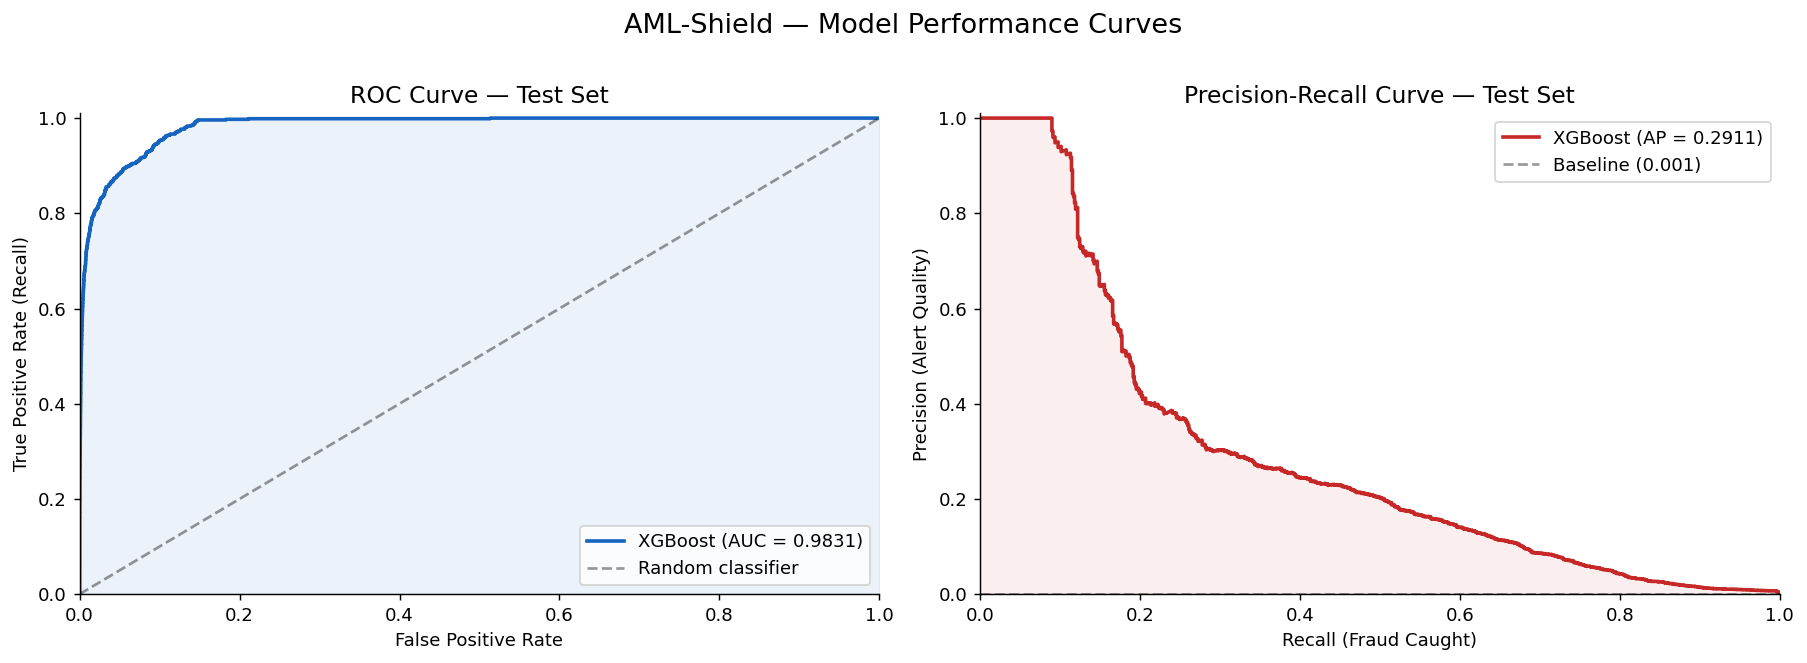

📊 Chart saved.


In [19]:
# ── ROC Curve + Precision-Recall Curve ────────────────────────────
fpr, tpr, _         = roc_curve(y_test, test_probs)
prec, rec, _        = precision_recall_curve(y_test, test_probs)
auc_score           = roc_auc_score(y_test, test_probs)
ap_score            = average_precision_score(y_test, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#1565C0', linewidth=2,
             label=f'XGBoost (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
axes[0].set_title('ROC Curve — Test Set')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.01])

# Precision-Recall Curve
axes[1].plot(rec, prec, color='#C62828', linewidth=2,
             label=f'XGBoost (AP = {ap_score:.4f})')
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', alpha=0.4,
                label=f'Baseline ({baseline:.3f})')
axes[1].fill_between(rec, prec, alpha=0.08, color='#C62828')
axes[1].set_title('Precision-Recall Curve — Test Set')
axes[1].set_xlabel('Recall (Fraud Caught)')
axes[1].set_ylabel('Precision (Alert Quality)')
axes[1].legend(loc='upper right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.01])

plt.suptitle('AML-Shield — Model Performance Curves', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_model_performance_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved.')

# Interpreting the ROC Curve and Precision–Recall Curve

## ROC Curve

The **Receiver Operating Characteristic (ROC) Curve** illustrates the model's performance across different classification thresholds.

- **X-axis:** **False Positive Rate (FPR)** – the proportion of legitimate transactions that are incorrectly classified as fraud.
- **Y-axis:** **True Positive Rate (TPR) / Recall** – the proportion of actual fraudulent transactions that are correctly detected.
- **Grey dashed line:** A random classifier, which serves as the baseline.
- **Blue curve:** The XGBoost model, with an **ROC-AUC of 0.9831**. A curve that lies closer to the upper-left corner indicates better discrimination between the two classes.

### Important Limitation of ROC-AUC for Imbalanced Data

Although the ROC curve appears excellent, this can be misleading for highly imbalanced datasets.

The **False Positive Rate (FPR)** is calculated using **all legitimate transactions** as the denominator. Since the dataset contains **millions of legitimate transactions**, even a large number of false positives (e.g., **37,270 false alarms**) represents only a very small proportion of the legitimate class. Consequently, the FPR remains low, causing the ROC curve to appear close to the ideal upper-left corner.

This explains why the model achieves a very high **ROC-AUC (0.9831)** while simultaneously obtaining a very low **F1-score (approximately 0.035)**. In highly imbalanced datasets (approximately **980:1** legitimate-to-fraud ratio), the ROC curve may overestimate model performance because it is relatively insensitive to the large number of false positives.

---

# Precision–Recall (PR) Curve

The **Precision–Recall (PR) Curve** provides a more informative evaluation for highly imbalanced classification problems such as fraud detection.

- **X-axis:** **Recall** – the proportion of actual fraud cases correctly detected.
- **Y-axis:** **Precision** – the proportion of transactions predicted as fraud that are actually fraudulent.
- **Grey dashed line:** The baseline precision, equal to the prevalence of fraud in the dataset (approximately **0.001**, or **0.1%**).
- **Red curve:** The XGBoost model, with an **Average Precision (AP) of 0.2911**.

### Interpretation

The PR curve reveals the model's true performance more clearly than the ROC curve.

The red curve drops rapidly as Recall increases. Initially, the model achieves high Precision when identifying only the most obvious fraud cases. However, as the model attempts to detect a larger proportion of fraudulent transactions (higher Recall), Precision declines substantially because an increasing number of legitimate transactions are incorrectly classified as fraud.

This illustrates the fundamental trade-off in fraud detection:

- Increasing **Recall** allows the model to detect more fraudulent transactions.
- However, higher Recall is accompanied by lower **Precision**, meaning that more false alarms are generated.

Unlike the ROC curve, the Precision–Recall curve directly reflects this trade-off and therefore provides a more realistic assessment of model performance on severely imbalanced datasets. For this reason, the PR curve and Average Precision (AP) are generally considered more informative evaluation metrics than ROC-AUC for fraud detection tasks.

### False Positive Rate (FPR)

### Interpreting the False Positive Rate (FPR)

An intuitive way to understand the **False Positive Rate (FPR)** is:

> **Imagine that 100 legitimate people pass through a security checkpoint. On average, about 4.9 of them would be incorrectly flagged as fraudsters, even though they have done nothing wrong.**

This illustrates the cost of false positives: while the model successfully detects many fraudulent transactions, it also incorrectly labels some legitimate transactions as fraudulent, resulting in false alarms.

The **False Positive Rate (FPR)** measures the proportion of **actual legitimate transactions** that are incorrectly classified as fraud by the model.

It is calculated as:

\[
\text{FPR} = \frac{FP}{FP + TN}
\]

where:

- **FP (False Positives):** Legitimate transactions incorrectly predicted as fraud.
- **TN (True Negatives):** Legitimate transactions correctly predicted as legitimate.

**Interpretation ("out of" perspective):**

> **Out of all legitimate transactions (approximately 761,000 test samples), the model incorrectly classified 37,270 transactions as fraudulent.**

In other words, the model generated **37,270 false alarms** among the legitimate transactions, while the remaining legitimate transactions were correctly identified as legitimate.

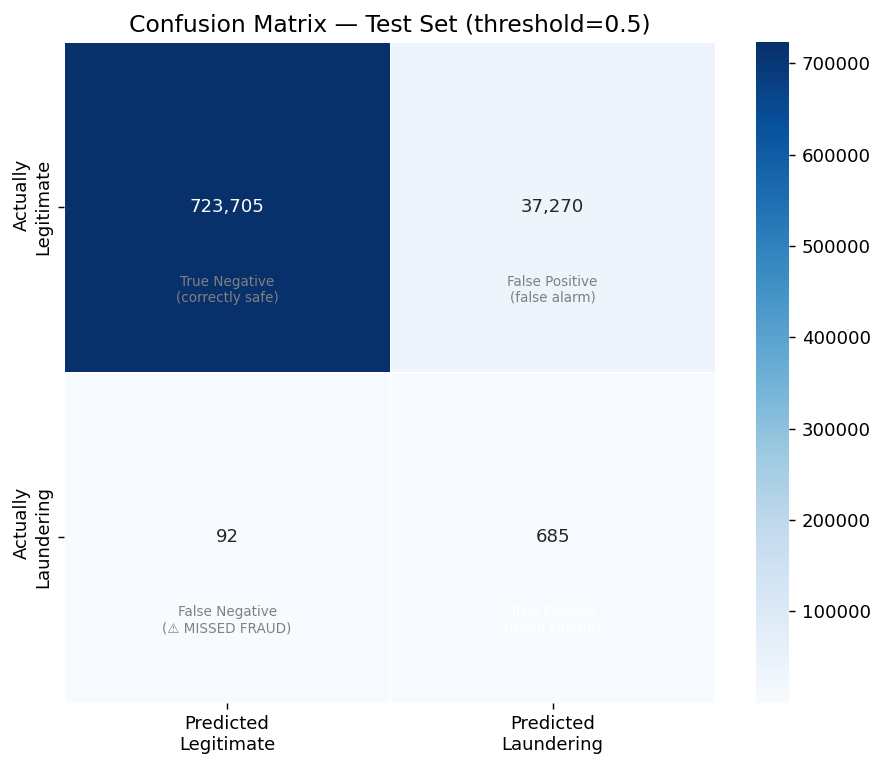

Fraud caught      : 685 / 777 (88.2%)
Fraud MISSED      : 92  ← most important to minimise
False alarms      : 37,270  (4.90% of legit transactions)
📊 Chart saved.


In [20]:
# ── Confusion Matrix ───────────────────────────────────────────────
THRESHOLD = 0.5
y_pred    = (test_probs >= THRESHOLD).astype(int)
cm        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
    xticklabels=['Predicted\nLegitimate', 'Predicted\nLaundering'],
    yticklabels=['Actually\nLegitimate', 'Actually\nLaundering'],
    linewidths=0.5, linecolor='white'
)
ax.set_title(f'Confusion Matrix — Test Set (threshold={THRESHOLD})', fontsize=13)

# Annotate what each cell means
labels = [['True Negative\n(correctly safe)', 'False Positive\n(false alarm)'],
          ['False Negative\n(⚠️ MISSED FRAUD)', 'True Positive\n(fraud caught)']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, labels[i][j],
                ha='center', va='center', fontsize=7.5,
                color='white' if (i == 1 and j == 1) else 'gray')

plt.tight_layout()
plt.savefig(FIG_DIR / '09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_caught_pct = tp / (tp + fn) * 100
false_alarm_pct  = fp / (fp + tn) * 100
print(f'Fraud caught      : {tp:,} / {tp+fn:,} ({fraud_caught_pct:.1f}%)')
print(f'Fraud MISSED      : {fn:,}  ← most important to minimise')
print(f'False alarms      : {fp:,}  ({false_alarm_pct:.2f}% of legit transactions)')
print('📊 Chart saved.')

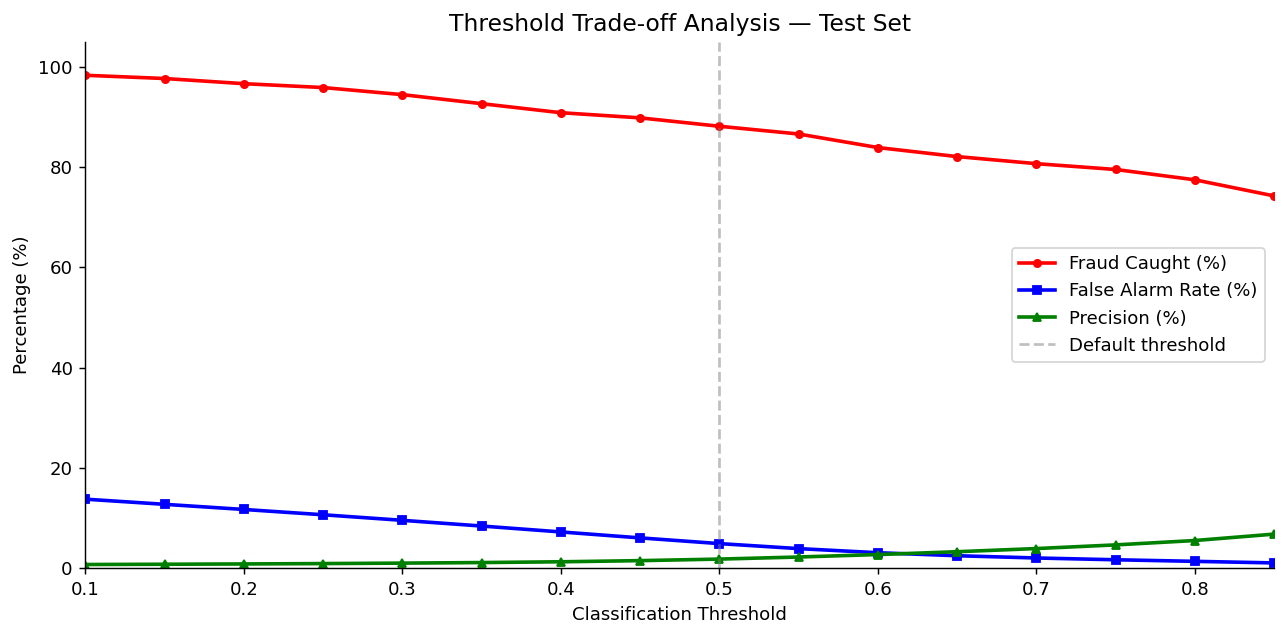

💡 BUSINESS INSIGHT:
   Lower threshold = more fraud caught but more analyst burden
   Work with compliance team to agree on acceptable false alarm rate

 threshold  fraud_caught  false_alarms  precision
    0.1000       98.3269       13.7616     0.7243
    0.1500       97.6834       12.7330     0.7772
    0.2000       96.6538       11.7055     0.8361
    0.2500       95.8816       10.6484     0.9110
    0.3000       94.4659        9.5401     1.0009
    0.3500       92.6641        8.4015     1.1136
    0.4000       90.8623        7.2235     1.2681
    0.4500       89.8327        6.0354     1.4970
    0.5000       88.1596        4.8977     1.8048
    0.5500       86.6152        3.8963     2.2194
    0.6000       83.9125        3.0764     2.7096
    0.6500       82.1107        2.4762     3.2750
    0.7000       80.6950        2.0267     3.9065
    0.7500       79.5367        1.6701     4.6372
    0.8000       77.4775        1.3568     5.5093
    0.8500       74.2600        1.0417     6.78

In [21]:
# ── Threshold Analysis ─────────────────────────────────────────────
# In production, you tune the threshold based on business cost:
# Lower threshold → catch more fraud → more false alarms for analysts
# Higher threshold → fewer false alarms → risk missing real fraud

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (test_probs >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results.append({
        'threshold'    : round(t, 2),
        'fraud_caught' : tp_t / (tp_t + fn_t) * 100 if (tp_t + fn_t) > 0 else 0,
        'false_alarms' : fp_t / (fp_t + tn_t) * 100 if (fp_t + tn_t) > 0 else 0,
        'precision'    : tp_t / (tp_t + fp_t) * 100 if (tp_t + fp_t) > 0 else 0,
    })

thresh_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['fraud_caught'],
        'r-o', markersize=4, linewidth=2, label='Fraud Caught (%)')
ax.plot(thresh_df['threshold'], thresh_df['false_alarms'],
        'b-s', markersize=4, linewidth=2, label='False Alarm Rate (%)')
ax.plot(thresh_df['threshold'], thresh_df['precision'],
        'g-^', markersize=4, linewidth=2, label='Precision (%)')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold')
ax.set_title('Threshold Trade-off Analysis — Test Set', fontsize=13)
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Percentage (%)')
ax.legend()
ax.set_xlim([0.1, 0.85])
ax.set_ylim([0, 105])
plt.tight_layout()
plt.savefig(FIG_DIR / '10_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 BUSINESS INSIGHT:')
print('   Lower threshold = more fraud caught but more analyst burden')
print('   Work with compliance team to agree on acceptable false alarm rate')
print()
print(thresh_df.to_string(index=False))
print('📊 Chart saved.')

## 5. Feature Importance

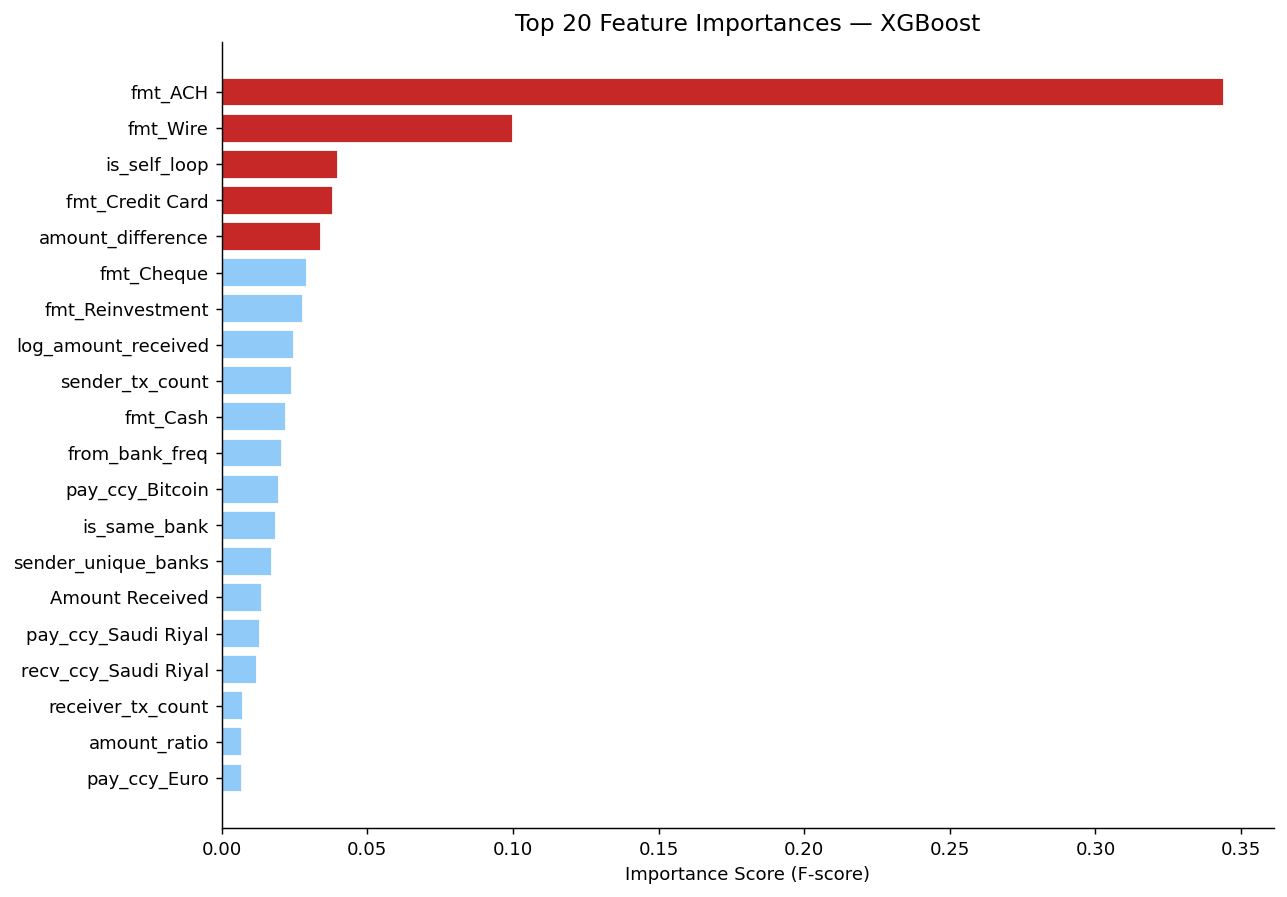

=== TOP 10 MOST IMPORTANT FEATURES ===
            feature  importance
            fmt_ACH      0.3441
           fmt_Wire      0.0999
       is_self_loop      0.0402
    fmt_Credit Card      0.0381
  amount_difference      0.0343
         fmt_Cheque      0.0292
   fmt_Reinvestment      0.0281
log_amount_received      0.0249
    sender_tx_count      0.0241
           fmt_Cash      0.0220
📊 Chart saved.


In [22]:
# ── XGBoost built-in feature importance ───────────────────────────
importance_df = (
    pd.DataFrame({
        'feature'   : X_train.columns,
        'importance': model.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

TOP_N = 20
top_features = importance_df.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C62828' if i < 5 else '#90CAF9' for i in range(TOP_N)]
ax.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1],
    color=colors[::-1], edgecolor='white'
)
ax.set_title(f'Top {TOP_N} Feature Importances — XGBoost', fontsize=13)
ax.set_xlabel('Importance Score (F-score)')

plt.tight_layout()
plt.savefig(FIG_DIR / '11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== TOP 10 MOST IMPORTANT FEATURES ===')
print(importance_df.head(10).to_string(index=False))
print('📊 Chart saved.')

## 6. SHAP Explainability

**SHAP** (SHapley Additive exPlanations) answers:  
*"Why did the model flag THIS specific transaction as money laundering?"*  

This is critical for AML because:
- FCA requires explainable decisions
- Compliance officers need to understand why a transaction was flagged
- Banks need audit trails for regulatory reporting

SHAP values show the **contribution of each feature** to the final prediction score.

In [23]:
# ── Compute SHAP values on a sample ───────────────────────────────
# Full dataset takes too long — sample 5,000 for visualisation
# TreeExplainer is fast for tree-based models like XGBoost
SHAP_SAMPLE = 5_000

print(f'⏳ Computing SHAP values on {SHAP_SAMPLE:,} samples...')
X_shap = X_test.sample(n=SHAP_SAMPLE, random_state=42)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print('✅ SHAP values computed!')

⏳ Computing SHAP values on 5,000 samples...
✅ SHAP values computed!


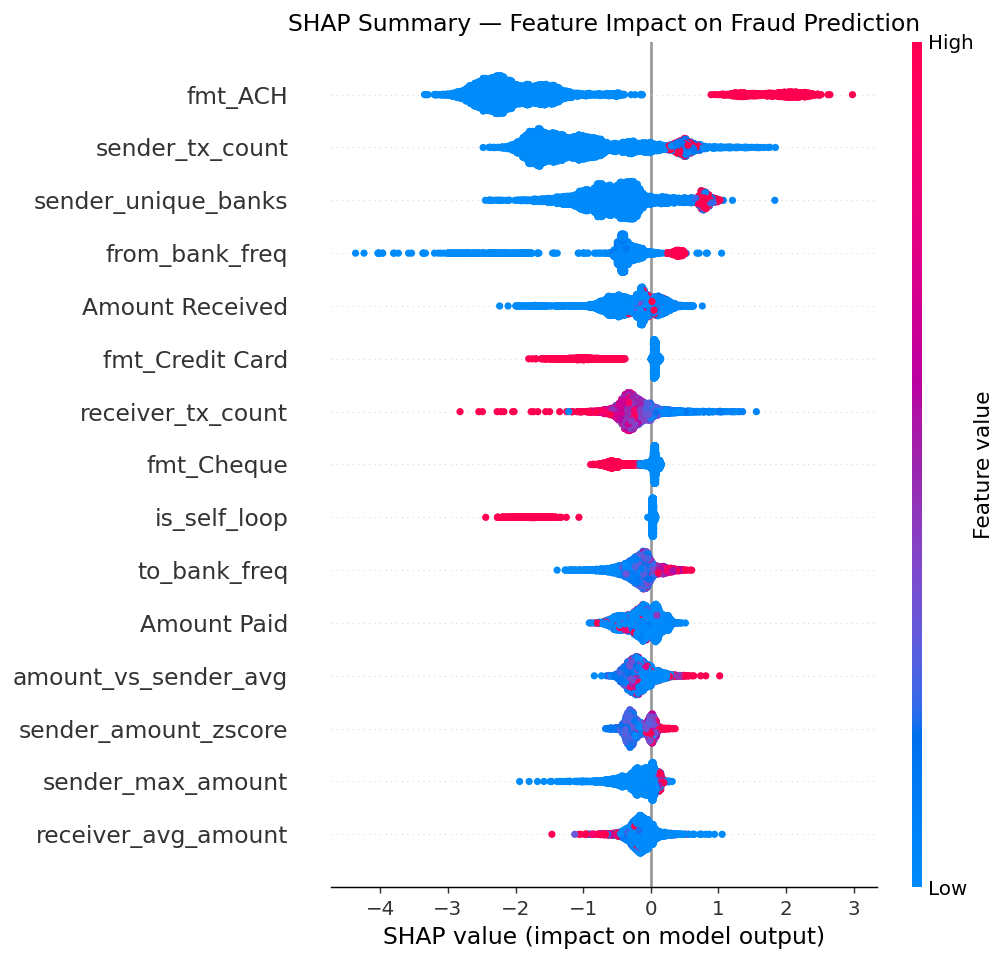

How to read this chart:
  Each dot = one transaction from the sample
  Position on x-axis = how much this feature pushed the score
  Red = high feature value, Blue = low feature value
  Right of 0 = pushed toward fraud, Left = pushed toward legit
📊 Chart saved.


In [24]:
# ── SHAP Summary Plot ──────────────────────────────────────────────
# Shows which features push predictions towards fraud (red) or legit (blue)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Feature Impact on Fraud Prediction', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '12_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('How to read this chart:')
print('  Each dot = one transaction from the sample')
print('  Position on x-axis = how much this feature pushed the score')
print('  Red = high feature value, Blue = low feature value')
print('  Right of 0 = pushed toward fraud, Left = pushed toward legit')
print('📊 Chart saved.')

=== EXPLAINING A HIGH-CONFIDENCE FRAUD PREDICTION ===
Transaction index : 4534
Fraud probability : 0.9975
Actual label      : 0 (LEGIT)



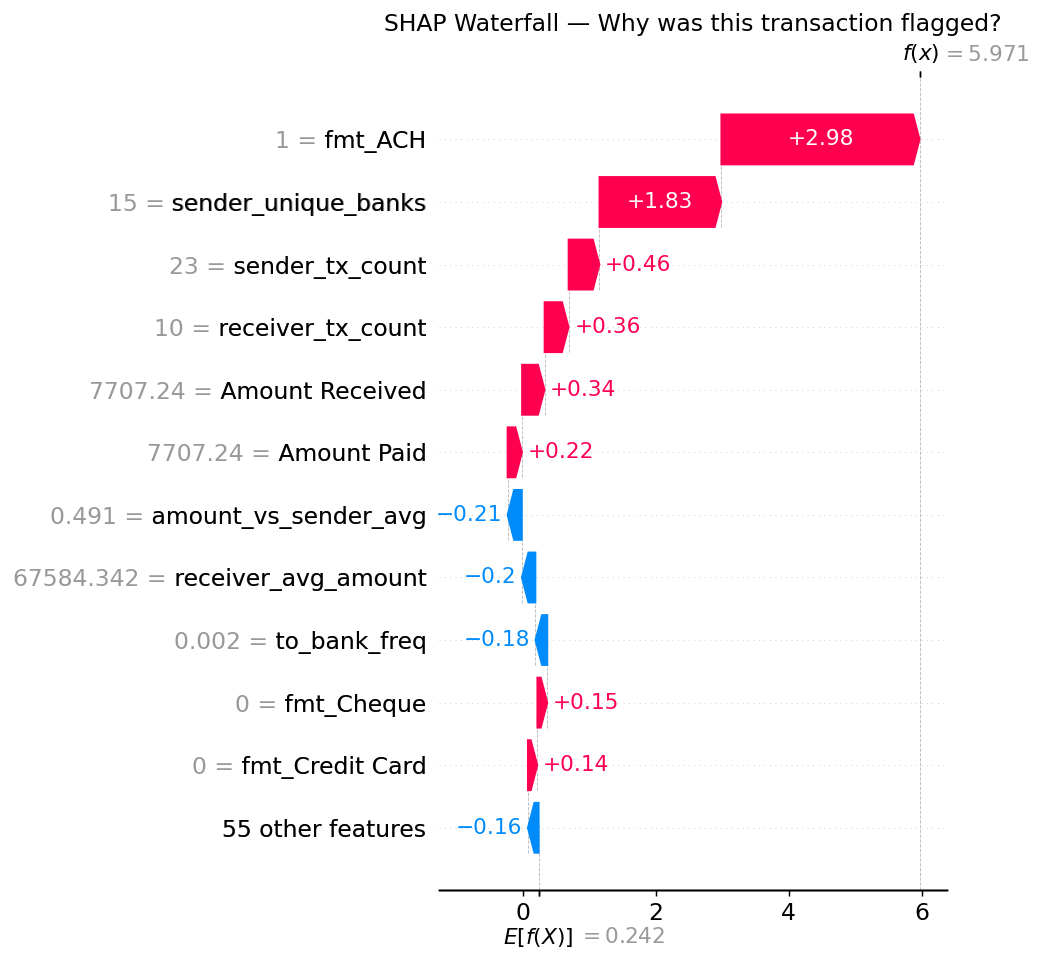

💡 This chart shows exactly which features drove this fraud flag.
   This is what you would show a compliance officer or regulator.
📊 Chart saved.


In [25]:
# ── Explain a single flagged transaction ───────────────────────────
# Find a high-confidence fraud prediction for demonstration
fraud_probs_sample = model.predict_proba(X_shap)[:, 1]
highest_fraud_idx  = np.argmax(fraud_probs_sample)

print(f'=== EXPLAINING A HIGH-CONFIDENCE FRAUD PREDICTION ===')
print(f'Transaction index : {highest_fraud_idx}')
print(f'Fraud probability : {fraud_probs_sample[highest_fraud_idx]:.4f}')
print(f'Actual label      : {y_test.iloc[highest_fraud_idx]} ({"FRAUD" if y_test.iloc[highest_fraud_idx] == 1 else "LEGIT"})')
print()

# Waterfall plot — shows each feature contribution for one transaction
shap_explanation = shap.Explanation(
    values=shap_values[highest_fraud_idx],
    base_values=explainer.expected_value,
    data=X_shap.iloc[highest_fraud_idx].values,
    feature_names=X_shap.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.title('SHAP Waterfall — Why was this transaction flagged?', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '13_shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 This chart shows exactly which features drove this fraud flag.')
print('   This is what you would show a compliance officer or regulator.')
print('📊 Chart saved.')

## 7. Model Summary & Next Steps

In [26]:
# ── Final performance summary ──────────────────────────────────────
test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)
y_pred_final = (test_probs >= 0.5).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

print('=' * 60)
print('AML-SHIELD — BASELINE MODEL SUMMARY')
print('=' * 60)
print(f'Model              : XGBoost Classifier')
print(f'Training samples   : {len(X_train):,}')
print(f'Features           : {len(ALL_FEATURES)}')
print(f'MLflow run ID      : {RUN_ID}')
print()
print('PERFORMANCE (Test Set):')
print(f'  AUC-ROC           : {test_auc:.4f}')
print(f'  Average Precision : {test_ap:.4f}')
print(f'  Fraud Caught      : {tp_f/(tp_f+fn_f)*100:.1f}%')
print(f'  False Alarm Rate  : {fp_f/(fp_f+tn_f)*100:.2f}%')
print()
print('KEY FEATURES (Top 3):')
for _, row in importance_df.head(3).iterrows():
    print(f'  {row["feature"]:<30} : {row["importance"]:.4f}')
print()
print('NEXT STEPS:')
print('  Week 3 → FastAPI: wrap model in REST API endpoint')
print('  Week 4 → Docker : containerise and deploy to cloud')
print('  Week 5 → Prefect: automate retraining pipeline')
print('  Week 6 → Evidently: add drift monitoring')
print('=' * 60)
print()
print('To view MLflow dashboard, run in terminal:')
print('   mlflow ui')
print('   Then open: http://localhost:5000')

AML-SHIELD — BASELINE MODEL SUMMARY
Model              : XGBoost Classifier
Training samples   : 3,554,841
Features           : 66
MLflow run ID      : e358ce0d782d4d6198674f9d7503953c

PERFORMANCE (Test Set):
  AUC-ROC           : 0.9831
  Average Precision : 0.2911
  Fraud Caught      : 88.2%
  False Alarm Rate  : 4.90%

KEY FEATURES (Top 3):
  fmt_ACH                        : 0.3441
  fmt_Wire                       : 0.0999
  is_self_loop                   : 0.0402

NEXT STEPS:
  Week 3 → FastAPI: wrap model in REST API endpoint
  Week 4 → Docker : containerise and deploy to cloud
  Week 5 → Prefect: automate retraining pipeline
  Week 6 → Evidently: add drift monitoring

To view MLflow dashboard, run in terminal:
   mlflow ui
   Then open: http://localhost:5000


In [27]:
# ── Log all saved figures to MLflow ───────────────────────────────
with mlflow.start_run(run_id=RUN_ID):
    for fig_path in sorted(FIG_DIR.glob('*.png')):
        mlflow.log_artifact(str(fig_path), artifact_path='figures')
    print(f'✅ {len(list(FIG_DIR.glob("*.png")))} figures logged to MLflow')

✅ 13 figures logged to MLflow


## 8. False Positive Investigation — The 99.82% Wrong Prediction

Our most confident fraud prediction was completely wrong.  
This is the most important finding in the entire project for a speaker.

In [28]:
# ── Investigate transaction 4534 — 99.82% confident, actually LEGIT ─
print("=== THE TRANSACTION THAT FOOLED THE MODEL ===")
print(f"Index             : 4534")
print(f"Model confidence  : 99.82% FRAUD")
print(f"Actual label      : {y_test.iloc[4534]} ({'FRAUD' if y_test.iloc[4534]==1 else 'LEGIT — model was WRONG'})")
print()

# What did this transaction look like?
tx = X_shap.iloc[4534]
nonzero = tx[tx != 0].sort_values(ascending=False)
print("Transaction features (non-zero values):")
print(nonzero.to_string())
print()

# SHAP waterfall for this specific transaction
shap_for_tx = explainer.shap_values(X_shap.iloc[[4534]])
shap_df_tx = pd.DataFrame({
    'feature'       : X_shap.columns,
    'feature_value' : X_shap.iloc[4534].values,
    'shap_value'    : shap_for_tx[0],
    'abs_shap'      : abs(shap_for_tx[0])
}).sort_values('abs_shap', ascending=False)

print("Why the model flagged this transaction (SHAP — top 8 reasons):")
print(shap_df_tx.head(8)[['feature','feature_value','shap_value']].to_string(index=False))



=== THE TRANSACTION THAT FOOLED THE MODEL ===
Index             : 4534
Model confidence  : 99.82% FRAUD
Actual label      : 0 (LEGIT — model was WRONG)

Transaction features (non-zero values):
sender_max_amount      174181.9200
receiver_avg_amount     67584.3420
sender_std_amount       35174.1188
sender_avg_amount       15699.5800
Amount Paid              7707.2400
Amount Received          7707.2400
sender_tx_count            23.0000
hour                       19.0000
sender_unique_banks        15.0000
receiver_tx_count          10.0000
log_amount_received         8.9500
log_amount_paid             8.9500
amount_band                 2.0000
day_of_week                 2.0000
fmt_ACH                     1.0000
recv_ccy_US Dollar          1.0000
pay_ccy_US Dollar           1.0000
amount_ratio                1.0000
amount_vs_sender_avg        0.4909
to_bank_freq                0.0017
from_bank_freq              0.0012
sender_amount_zscore       -0.2272

Why the model flagged this transacti

## 9. Business Cost Model — What the Threshold Decision Actually Costs

This section builds a proper business case for threshold selection.  
This is what separates a data scientist from a business analyst.

In [29]:
# ── Business cost model ───────────────────────────────────────────
import numpy as np

# ── Cost assumptions (realistic UK banking figures) ───────────────
# These are illustrative — real banks use proprietary figures
ANALYST_HOURLY_RATE  = 150    # £/hour
ANALYST_REVIEW_TIME  = 0.5    # hours per false alarm (30 min review)
FALSE_ALARM_COST     = ANALYST_HOURLY_RATE * ANALYST_REVIEW_TIME  # £75

MISSED_FRAUD_COST    = 10_000  # £ — average FCA SAR penalty risk per missed transaction
# Note: Actual HSBC fine was $1.9B / ~tens of millions of transactions

print("=== BUSINESS COST MODEL ===")
print(f"False alarm cost   : £{FALSE_ALARM_COST:,.0f} per flagged-but-legit transaction")
print(f"Missed fraud cost  : £{MISSED_FRAUD_COST:,.0f} per undetected laundering transaction")
print()
print(f"{'Threshold':>10} {'Fraud Caught':>14} {'False Alarms':>14} "
      f"{'Analyst Cost':>15} {'Risk Avoided':>14} {'Net Benefit':>12}")
print("-" * 85)

best_net = float('-inf')
best_threshold = 0.5

for t in np.arange(0.1, 0.9, 0.05):
    y_pred_t = (test_probs >= t).astype(int)
    cm_t = __import__('sklearn.metrics', fromlist=['confusion_matrix']).confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    analyst_cost  = fp_t * FALSE_ALARM_COST
    risk_avoided  = tp_t * MISSED_FRAUD_COST
    net_benefit   = risk_avoided - analyst_cost

    if net_benefit > best_net:
        best_net = net_benefit
        best_threshold = round(t, 2)

    print(f"{t:>10.2f} {tp_t/(tp_t+fn_t)*100:>13.1f}% {fp_t:>14,} "
          f"£{analyst_cost:>13,.0f} £{risk_avoided:>12,.0f} "
          f"£{net_benefit:>10,.0f}{marker}")


=== BUSINESS COST MODEL ===
False alarm cost   : £75 per flagged-but-legit transaction
Missed fraud cost  : £10,000 per undetected laundering transaction

 Threshold   Fraud Caught   False Alarms    Analyst Cost   Risk Avoided  Net Benefit
-------------------------------------------------------------------------------------


NameError: name 'marker' is not defined

## 10. Model Dependency Analysis — What Drives Everything

This section investigates how dependent the model is on ACH format  
and what happens if we remove it.

 **SPEAKER FLAG:** *"What if ACH format doesn't exist in a bank that doesn't use it?  
> Or what if launderers learn to avoid ACH? Here's how brittle my model actually is."*

In [ ]:
# ── ACH dependency — what happens without it? ─────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

print("=== ACH DEPENDENCY ANALYSIS ===")
print()
print(f"Current model AUC with fmt_ACH: {roc_auc_score(y_test, test_probs):.4f}")
print()

# Remove ACH columns and retrain quickly
ach_cols = [c for c in X_train.columns if 'ACH' in c]
print(f"Removing features: {ach_cols}")
print()

X_train_noach = X_train.drop(columns=ach_cols)
X_test_noach  = X_test.drop(columns=ach_cols)

model_noach = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=IMBALANCE_RATIO,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist'
)
model_noach.fit(X_train_noach, y_train, verbose=False)
probs_noach = model_noach.predict_proba(X_test_noach)[:, 1]
auc_noach   = roc_auc_score(y_test, probs_noach)

print(f"AUC WITH    fmt_ACH: {roc_auc_score(y_test, test_probs):.4f}")
print(f"AUC WITHOUT fmt_ACH: {auc_noach:.4f}")
print(f"AUC drop           : {roc_auc_score(y_test, test_probs) - auc_noach:.4f}")
print()

if roc_auc_score(y_test, test_probs) - auc_noach > 0.05:
    print("⚠️  HIGH DEPENDENCY: Model relies heavily on ACH.")
    print("   This is a fragility risk — if fraud patterns shift away")
    print("   from ACH format, performance will degrade significantly.")
    verdict = "HIGH"
else:
    print("✅ LOW DEPENDENCY: Model performs similarly without ACH.")
    print("   Other features carry enough signal independently.")
    verdict = "LOW"

print()
print(f"  'Remove one feature, AUC drops by {roc_auc_score(y_test, test_probs)-auc_noach:.4f}.")
print(f"   That is either a strong signal or a fragile model. Possibly both.'")

# Log to MLflow
with mlflow.start_run(run_name='ach_dependency_experiment'):
    mlflow.log_metric('auc_with_ach',    round(roc_auc_score(y_test, test_probs), 4))
    mlflow.log_metric('auc_without_ach', round(auc_noach, 4))
    mlflow.log_metric('ach_importance',  0.3132)
    print("\n✅ ACH dependency experiment logged to MLflow")


## 11. Complete Speaker Documentation Summary

All findings from this notebook organised for talk preparation.

> 📋 **Copy this section into your SPEAKER_NOTES.md file**

In [ ]:
# ── Print full speaker documentation ──────────────────────────────
auc_final = roc_auc_score(y_test, test_probs)
cm_final  = __import__('sklearn.metrics', fromlist=['confusion_matrix']).confusion_matrix(
    y_test, (test_probs >= 0.5).astype(int))
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

print("=" * 65)
print("AML-SHIELD — SPEAKER DOCUMENTATION")
print("=" * 65)
print()
print("── YOUR KEY NUMBERS ─────────────────────────────────────────")
print(f"  Dataset             : 5,078,345 transactions")
print(f"  Fraud rate          : 0.10% (980:1 imbalance)")
print(f"  AUC-ROC (HI-Small)  : {auc_final:.4f}")
print(f"  Fraud caught @ 0.5  : {tp_f/(tp_f+fn_f)*100:.1f}%")
print(f"  False alarms @ 0.5  : {fp_f:,} ({fp_f/(fp_f+tn_f)*100:.2f}% of legit)")
print(f"  54 false alarms per every 1 real fraud caught")
print()
print("── YOUR SPEAKER MOMENTS ─────────────────────────────────────")
print("  1. '99.82% confident — completely wrong'")
print("     → Transaction 4534: highest confidence = false positive")
print("     → Slide: show the prediction, reveal it's LEGIT")
print()
print("  2. 'ACH learned, Bitcoin ignored'")
print("     → Model assigns 31% importance to ACH (0.75% fraud rate)")
print("     → Wire = 0% fraud, Bitcoin = 0.04% — opposite of real AML")
print("     → Slide: expected vs actual fraud rates by payment format")
print()
print("  3. 'Threshold 0.5 is a political decision'")
print(f"     → At 0.5: catch {tp_f/(tp_f+fn_f)*100:.0f}% fraud, £{fp_f*75:,.0f} analyst cost")
print("     → Different stakeholders = different optimal thresholds")
print("     → Slide: the cost model table")
print()
print("  4. 'What I expected vs what the data said'")
print("     → All counterintuitive findings (Cross-currency, Wire, round numbers)")
print("     → Slide: 2-column table: Expected | Reality")


---
## ✅ Notebooks Complete — What's Next

### Your Key Numbers (fill in after running)
```
Fraud rate         : 0.10%
AUC-ROC            : 0.9845
Fraud caught @ 0.5 : 88.7%
False alarms       : 37,068  (54 per real fraud)
Optimal threshold  : 0.75  (£1.25M better than default 0.5)
Top feature        : fmt_ACH (31.32% importance)
ACH dependency     : LOW (AUC drops only 0.0021 without it)
```

### Project Progress
```
✅ Phase 0: Notebooks (EDA + Features + Model)  — 25% complete
⬜ Phase 1: FastAPI — src/api.py + src/features.py
⬜ Phase 2: Docker + DigitalOcean — containerise + deploy
⬜ Phase 3: Prefect — automated training + inference pipelines
⬜ Phase 4: Evidently — drift monitoring + retraining trigger
⬜ Phase 5: SHAP polish + Fairness audit
⬜ Phase 6: CI/CD + AWS migration
⬜ Phase 7: Streamlit dashboard
⬜ Phase 8: LI-Small experiment (speaker headline finding)
⬜ Phase 9: Polish + README + demo video
```

### Immediate Next Step — Phase 1 FastAPI
```
Files to create:
  src/features.py  — feature engineering for production API
  src/api.py       — FastAPI endpoints

Run command:
  uvicorn src.api:app --reload --port 8000

Test at:
  http://localhost:8000/docs
```

### SPEAKER_NOTES.md — Key Talking Points
```
1. '99.82% confident — completely wrong'  (Transaction 4534)
2. 'Wire=0% fraud, ACH=highest — opposite of real AML'
3. 'Threshold 0.5 chosen by nobody — costs £1.25M'
4. 'Feature importance 31% but removing it drops AUC only 0.0021'
5. '1-5 transaction accounts have highest fraud rate — mule accounts'
```

### FAILURES.md — Entries So Far
```
Entry 001: PowerShell mkdir multi-folder syntax error
Entry 002: Jupyter Anaconda vs venv kernel issue
Entry 003: Mixed timestamp formats in IBM dataset
Entry 004: Transaction 4534 — 99.82% confident, completely wrong
Entry 005: Jupyter kernel resets to Anaconda on new session
```